In [3]:
import pandas as pd
import random

# Number of records
num_records = 100

# Sample data
products = [
    ("Laptop", "Electronics", 55000),
    ("Mouse", "Electronics", 500),
    ("Keyboard", "Electronics", 1500),
    ("Monitor", "Electronics", 15000),
    ("Printer", "Electronics", 22000),
    ("Office Chair", "Furniture", 12000),
    ("Desk", "Furniture", 18000),
    ("Notebook", "Stationery", 100),
    ("Pen Pack", "Stationery", 20),
    ("File Folder", "Stationery", 30)
]

data = {
    "order_id": [],
    "order_date": [],
    "product_name": [],
    "category": [],
    "quantity": [],
    "unit_price": []
}

for i in range(num_records):
    product, category, price = random.choice(products)

    data["order_id"].append(1001 + i)
    data["order_date"].append(pd.to_datetime("2025-01-01") + pd.to_timedelta(random.randint(0, 60), unit="D"))
    data["product_name"].append(product)
    data["category"].append(category)
    data["quantity"].append(random.randint(1, 30))
    data["unit_price"].append(price)

sales_df = pd.DataFrame(data)

sales_df.head()


,order_id,order_date,product_name,category,quantity,unit_price
0,1001,2025-01-15,Mouse,Electronics,1,500
1,1002,2025-01-04,Printer,Electronics,14,22000
2,1003,2025-01-20,Mouse,Electronics,1,500
3,1004,2025-02-23,Desk,Furniture,8,18000
4,1005,2025-02-09,Pen Pack,Stationery,1,20


In [5]:


sales_df["total_amount"] = sales_df["quantity"] * sales_df["unit_price"]
sales_df.head()


,order_id,order_date,product_name,category,quantity,unit_price,total_amount
0,1001,2025-01-15,Mouse,Electronics,1,500,500
1,1002,2025-01-04,Printer,Electronics,14,22000,308000
2,1003,2025-01-20,Mouse,Electronics,1,500,500
3,1004,2025-02-23,Desk,Furniture,8,18000,144000
4,1005,2025-02-09,Pen Pack,Stationery,1,20,20


In [6]:
total_revenue = sales_df["total_amount"].sum()
total_orders = sales_df["order_id"].count()

total_revenue, total_orders
print("Total Revenue:", total_revenue)
print("Total Orders:", total_orders)


Total Revenue: 23648780
Total Orders: 100


In [7]:
product_sales = sales_df.groupby("product_name")["total_amount"].sum().reset_index()

product_sales


,product_name,total_amount
0,Desk,2358000
1,File Folder,4020
2,Keyboard,172500
3,Laptop,10890000
4,Monitor,2805000
5,Mouse,59500
6,Notebook,8300
7,Office Chair,2880000
8,Pen Pack,5460
9,Printer,4466000


In [10]:
product_sales_sorted = product_sales.sort_values(by="total_amount")
product_sales_sorted
print("Lowest selling product:")
print(product_sales_sorted.iloc[0])

print("\nHighest selling product:")
print(product_sales_sorted.iloc[-1])


Lowest selling product:
product_name    File Folder
total_amount           4020
Name: 1, dtype: object

Highest selling product:
product_name      Laptop
total_amount    10890000
Name: 3, dtype: object


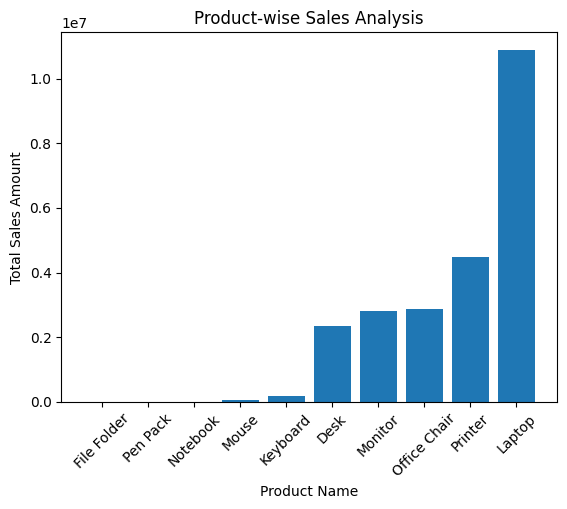

In [11]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(product_sales_sorted["product_name"], product_sales_sorted["total_amount"])
plt.xticks(rotation=45)
plt.xlabel("Product Name")
plt.ylabel("Total Sales Amount")
plt.title("Product-wise Sales Analysis")
plt.show()



In [13]:
product_sales_sorted["sales_percentage"] = (
    product_sales_sorted["total_amount"] / total_revenue
) * 100

product_sales_sorted


,product_name,total_amount,sales_percentage
1,File Folder,4020,0.016999
8,Pen Pack,5460,0.023088
6,Notebook,8300,0.035097
5,Mouse,59500,0.251599
2,Keyboard,172500,0.729425
0,Desk,2358000,9.970916
4,Monitor,2805000,11.861077
7,Office Chair,2880000,12.178218
9,Printer,4466000,18.884695
3,Laptop,10890000,46.048887


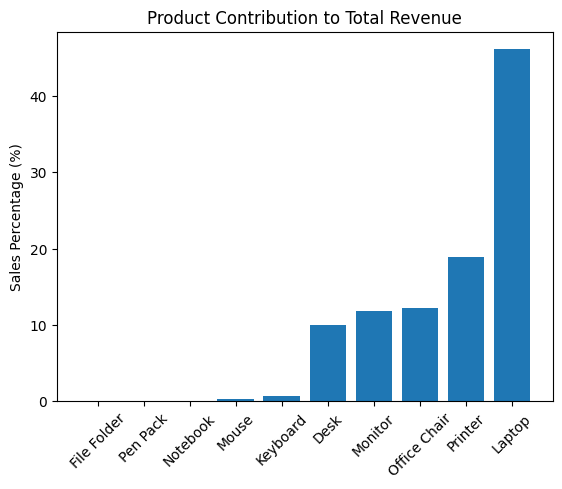

In [14]:
plt.figure()
plt.bar(product_sales_sorted["product_name"], product_sales_sorted["sales_percentage"])
plt.xticks(rotation=45)
plt.ylabel("Sales Percentage (%)")
plt.title("Product Contribution to Total Revenue")
plt.show()


In [15]:
category_sales = sales_df.groupby("category")["total_amount"].sum().reset_index()
category_sales


,category,total_amount
0,Electronics,18393000
1,Furniture,5238000
2,Stationery,17780


In [16]:
category_sales_sorted = category_sales.sort_values(by="total_amount")
category_sales_sorted


,category,total_amount
2,Stationery,17780
1,Furniture,5238000
0,Electronics,18393000


In [17]:
print("Lowest selling category:")
print(category_sales_sorted.iloc[0])
print("\nHighest selling category:")
print(category_sales_sorted.iloc[-1])


Lowest selling category:
category        Stationery
total_amount         17780
Name: 2, dtype: object

Highest selling category:
category        Electronics
total_amount       18393000
Name: 0, dtype: object


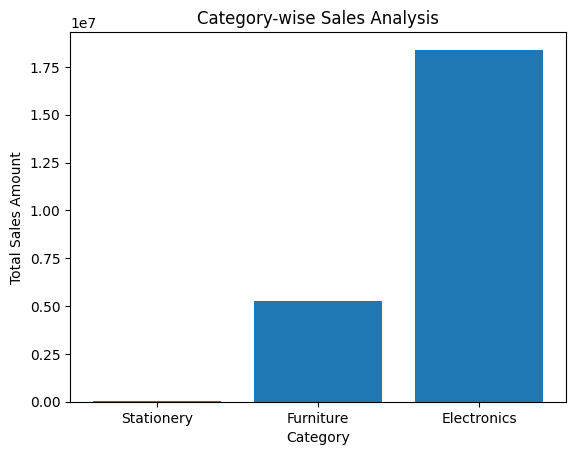

In [18]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(category_sales_sorted["category"], category_sales_sorted["total_amount"])
plt.xlabel("Category")
plt.ylabel("Total Sales Amount")
plt.title("Category-wise Sales Analysis")
plt.show()


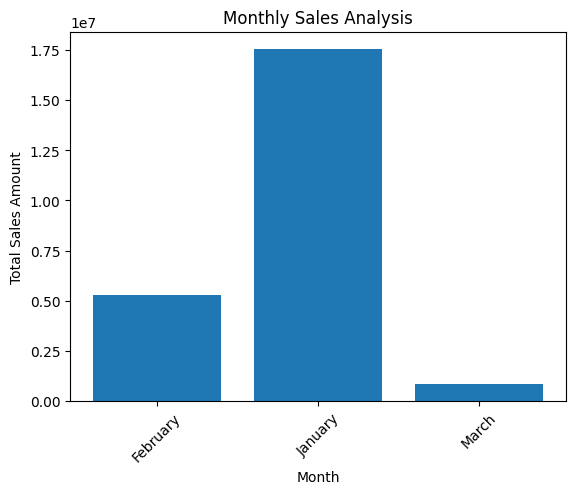

In [19]:
sales_df["order_date"].dt.month_name()
monthly_sales = (
    sales_df
    .groupby(sales_df["order_date"].dt.month_name())["total_amount"]
    .sum()
    .reset_index(name="total_amount")
)

monthly_sales
import matplotlib.pyplot as plt

plt.figure()
plt.bar(monthly_sales["order_date"], monthly_sales["total_amount"])
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Total Sales Amount")
plt.title("Monthly Sales Analysis")
plt.show()


In [22]:

"""Business Summary

This sales data analysis project examined 100 sales records to understand overall business performance.

The total revenue generated from all orders is ₹23,648,780, with a total of 100 orders placed during the period.

Product-wise analysis shows that Laptop is the highest-performing product, contributing the maximum share of total revenue, while File Folder is the lowest-selling product.

Category-wise analysis indicates that the Electronics category generates the highest revenue due to high-value products, whereas Stationery contributes the least.

Monthly sales analysis shows variations in revenue across different months, helping identify periods of higher and lower sales activity.

Overall, the analysis provides clear insights into top-performing products and categories, which can support better business decision-making and sales planning."""

'Business Summary\n\nThis sales data analysis project examined 100 sales records to understand overall business performance.\n\nThe total revenue generated from all orders is ₹23,648,780, with a total of 100 orders placed during the period.\n\nProduct-wise analysis shows that Laptop is the highest-performing product, contributing the maximum share of total revenue, while File Folder is the lowest-selling product.\n\nCategory-wise analysis indicates that the Electronics category generates the highest revenue due to high-value products, whereas Stationery contributes the least.\n\nMonthly sales analysis shows variations in revenue across different months, helping identify periods of higher and lower sales activity.\n\nOverall, the analysis provides clear insights into top-performing products and categories, which can support better business decision-making and sales planning.'

In [23]:
sales_df.to_csv("week2_sales_analysis_output.csv", index=False)
print("CSV file exported successfully")


CSV file exported successfully
